# The Time Diversification Effect
The purpose of this notebook is to demonstrate the risk reducing effect of investing over 
longer periods.

Whilst short-term volatility can lead to wild price swings, long-term investments benefit 
from averaging of returns, allowing periods of market growth to offset any short-term 
losses.

## Imports

In [1]:
import pandas as pd
import numpy as np
import random
from matplotlib import pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import date
from dateutil.relativedelta import relativedelta

from trading_algos import optimization as tao
from trading_algos import datasets as tad
from trading_algos import plots as tap
from trading_algos import utils as tau
from trading_algos.utils import head_tail as ht

%load_ext autoreload
%autoreload 2

2026-06-03 15:32:05.050 | INFO     | trading_algos.config:<module>:11 - PROJ_ROOT path is: /home/jamie/code/JamieW365/trading_algos


## Load Data

In [2]:
# Load a complete collection of S&P500 stocks from repository
# Not interested in survivors here
df_stocks = tad.get_sp500(survivors=False)

In [3]:
ht(df_stocks)

Price            Close                                                       \
Ticker               A         AA    AAL        AAP        AAPL        ABBV   
Date                                                                          
1962-01-02         NaN   1.473408    NaN        NaN         NaN         NaN   
1962-01-03         NaN   1.495946    NaN        NaN         NaN         NaN   
1962-01-04         NaN   1.495946    NaN        NaN         NaN         NaN   
2026-03-12  111.629997  65.930000  10.55  52.660000  255.759995  225.369995   
2026-03-13  111.510002  63.590000  10.30  51.730000  250.119995  219.679993   
2026-03-16  111.830002  66.599998  10.49  53.189999  252.820007  221.449997   

Price                                              ...    Volume             \
Ticker            ABNB ABS         ABT       ACGL  ...       XOM       XRAY   
Date                                               ...                        
1962-01-02         NaN NaN         NaN        NaN  ...    902400        NaN   
1962-01-03         NaN NaN         NaN        NaN  ...   1200000        NaN   
1962-01-04         NaN NaN         NaN        NaN  ...   1088000        NaN   
2026-03-12  127.699997 NaN  108.139999  94.220001  ...  26054000  4793400.0   
2026-03-13  126.300003 NaN  108.029999  93.470001  ...  22414100  5267000.0   
2026-03-16  128.320007 NaN  109.949997  93.699997  ...  14735861  3467391.0   

Price                                                                      \
Ticker          XRX        XYL        XYZ        YUM        ZBH      ZBRA   
Date                                                                        
1962-01-02    51233        NaN        NaN        NaN        NaN       NaN   
1962-01-03    51233        NaN        NaN        NaN        NaN       NaN   
1962-01-04   198099        NaN        NaN        NaN        NaN       NaN   
2026-03-12  2359700  1626400.0  8599800.0  1781000.0  3184500.0  849300.0   
2026-03-13  2888800  1842200.0  7134200.0  1119600.0  1818300.0  755500.0   
2026-03-16  3141624  1646872.0  6071738.0  2191490.0  1955785.0  577565.0   

Price                             
Ticker           ZION        ZTS  
Date                              
1962-01-02        NaN        NaN  
1962-01-03        NaN        NaN  
1962-01-04        NaN        NaN  
2026-03-12  1579700.0  3955100.0  
2026-03-13  1412900.0  3783200.0  
2026-03-16  1029592.0  3665230.0  

[6 rows x 3300 columns]

In [4]:
df_stocks.shape

(16158, 3300)

In [5]:
print(df_stocks.columns.get_level_values(1).nunique(), 'stocks')

660 stocks


## Simulating Returns Across Widening Investment Horizons

In [17]:
prob_beat_rf = []
summary_dict = {}

# Looping through investment windows increasing by 1 month intervals
# Up to 30 years
for i in range(1, 360+1):

    # Log returns for the investment horizon
    ann_rolling_log_return = (log_prices - log_prices.shift(i * 21)) / (i / 12)
    
    # Probability of positive returns over the investment horizon
    prob_beat_rf.append(
        ((ann_rolling_log_return > 0)* 1)\
            .mask(ann_rolling_log_return.isna(), np.nan)\
                .mean()\
                    .mean())
    
    # Gather and store summary statistics for the investment period
    summary_dict[i] = ann_rolling_log_return\
        .describe(percentiles=[0.05, 0.95]).mean(axis=1)

# Store all summaries in a dataframe
df_summary = pd.DataFrame(summary_dict).T.drop(columns='count')
df_summary.columns = ['CAGR', 'Ann.Risk', 'MinRet', '5%', '50%', '95%', 'MaxRet']
# Convert log growth back into actual CAGR
df_summary['CAGR'] = np.exp(df_summary['CAGR']) - 1 # Converting annualized log returns into conventional CAGR
df_summary['Total Return'] = ((1 + df_summary['CAGR']) ** df_summary.index) - 1
df_summary['Profit Likelihood'] = prob_beat_rf
df_summary.index.name = 'Months Held'

## Visualizing Performance as Investment Horizon Increases

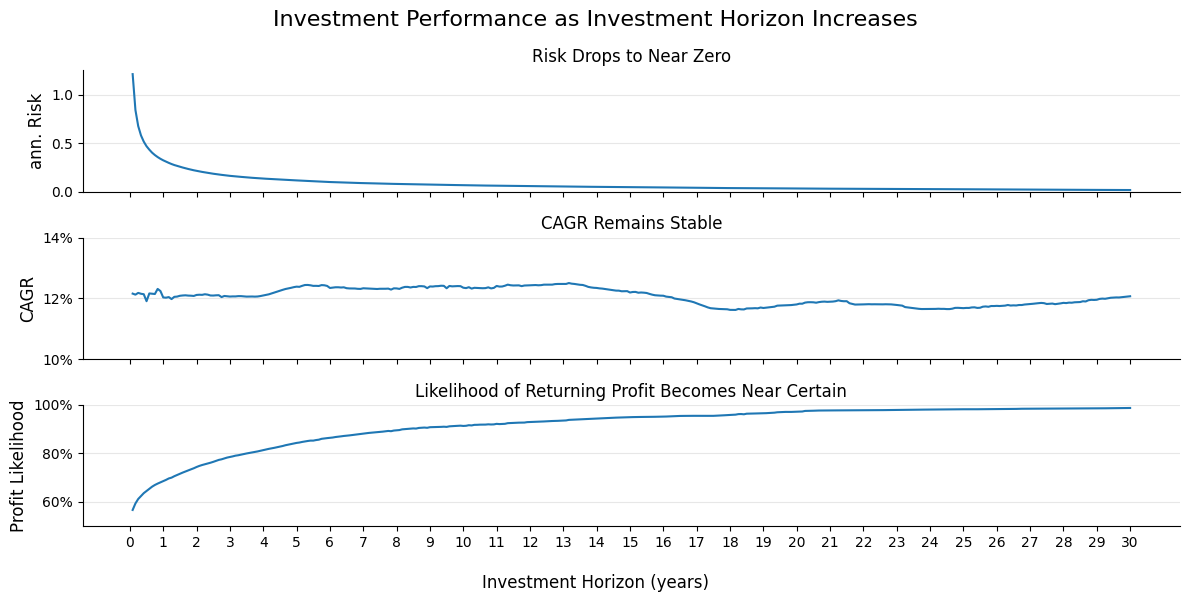

In [18]:
fig, ax = plt.subplots(3, 1, figsize=(12, 6), tight_layout=True, sharex=True)

fig.suptitle('Investment Performance as Investment Horizon Increases', fontsize=16)
fig.supxlabel('Investment Horizon (years)')

ax[0].set_title('Risk Drops to Near Zero')
ax[0].set_ylabel('ann. Risk',fontsize=12)
ax[0].plot(df_summary['Ann.Risk'])
ax[0].set_ylim(0,1.25)
ax[0].set_xticks(np.arange(0,len(df_summary)))
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].grid(axis='y', alpha=0.3)


ax[1].set_title('CAGR Remains Stable')
ax[1].set_ylabel('CAGR',fontsize=12)
ax[1].plot(df_summary['CAGR'])
ax[1].set_ylim(0.1,0.14)
ax[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax[1].set_xticks(np.arange(0,len(df_summary)))
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].grid(axis='y', alpha=0.3)

ax[2].set_title('Likelihood of Returning Profit Becomes Near Certain')
ax[2].set_ylabel('Profit Likelihood',fontsize=12)
ax[2].plot(df_summary['Profit Likelihood'])
ax[2].set_ylim(0.5,1)
ax[2].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax[2].set_xticks(np.arange(0,len(df_summary)))
ax[2].spines[['top', 'right']].set_visible(False)
ax[2].grid(axis='y', alpha=0.3)

plt.xticks(ticks=np.arange(0, df_summary.index[-1]+1, 12), 
           labels=(np.arange(0, df_summary.index[-1]+1, 12)/12).astype(int))
plt.show();

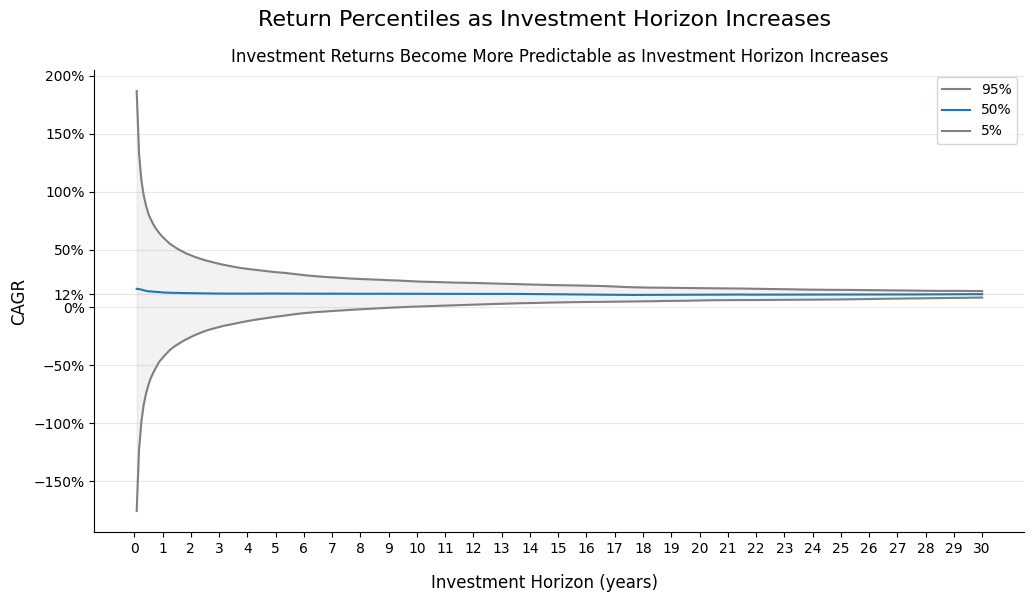

In [19]:
fig, ax = plt.subplots(figsize=(12, 6))

fig.suptitle('Return Percentiles as Investment Horizon Increases', fontsize=16)
fig.supxlabel('Investment Horizon (years)')

ax.set_title('Investment Returns Become More Predictable as Investment Horizon Increases')
ax.set_ylabel('CAGR',fontsize=12)

ax.plot(df_summary['95%'], color='grey', label='95%')
ax.plot(df_summary['50%'], label='50%')
ax.plot(df_summary['5%'], color='grey', label='5%')

ax.set_yticks(np.sort(np.append(ax.get_yticks(),df_summary['50%'].mean())))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))

ax.set_xticks(np.arange(0,len(df_summary)))

ax.axhline(y=df_summary['50%'].mean(), color='grey', linewidth=0.03)
ax.fill_between(x=df_summary.index,
                y1=df_summary['5%'], 
                y2=df_summary['95%'], 
                color='grey', 
                alpha=0.1)

ax.legend()

ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.xticks(ticks=np.arange(0, df_summary.index[-1]+1, 12), 
           labels=(np.arange(0, df_summary.index[-1]+1, 12)/12).astype(int))
plt.show();




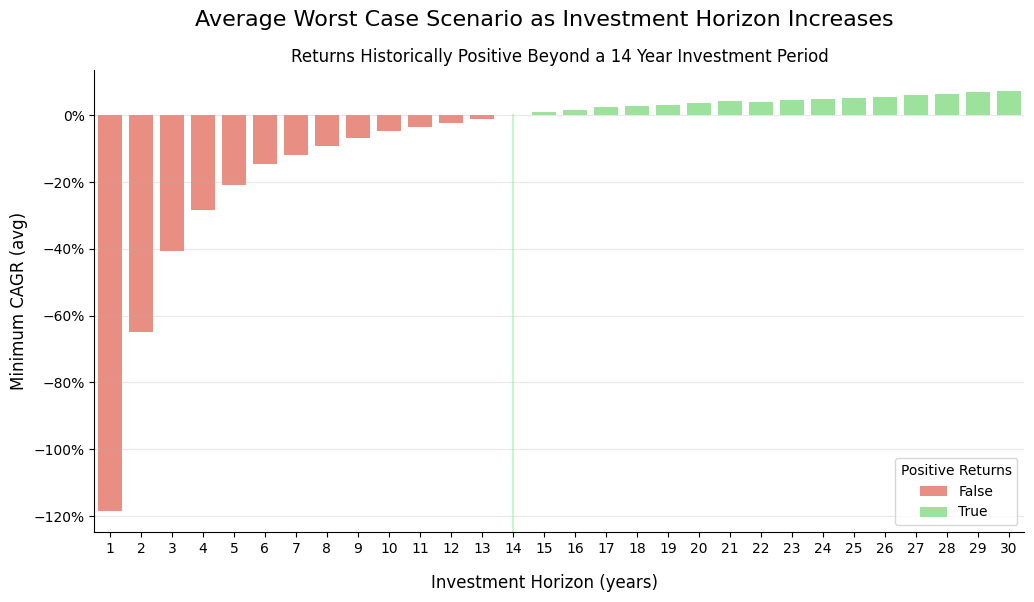

In [20]:
fig, ax = plt.subplots(figsize=(12, 6))

fig.suptitle('Average Worst Case Scenario as Investment Horizon Increases', fontsize=16)
ax.set_title('Returns Historically Positive Beyond a 14 Year Investment Period')


fig.supxlabel('Investment Horizon (years)')

ax.set_ylabel('Minimum CAGR (avg)',fontsize=12)
ax.set_xlabel(' ')

df_plot = df_summary.iloc[11::12].copy()

sns.barplot(x=df_plot.index, 
            y=df_plot['MinRet'],
            hue=df_plot['MinRet']>0,
            palette=['salmon', 'lightgreen'])

ax.axvline(df_plot[df_plot['MinRet']>0]['MinRet'].index[0]/12-1,
           ymax=abs(ax.get_ylim()[0] / (ax.get_ylim()[1] - ax.get_ylim()[0])),
           color='lightgreen',
           alpha=0.5)

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
ax.set_xticks(ticks=np.arange(0,30),
              labels=np.arange(1,31))

ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

ax.legend().set_title('Positive Returns')

plt.show();